# Notebook 18 — Full Pipeline: From Pixels to 3D Map

**Vision & 3D Mapping Workshop** | Block 7: Capstone

---

## The Complete System

This capstone notebook integrates ALL modules from the workshop into
a complete mapping pipeline:

### What You'll Learn

- How to wire together feature detection, visual odometry, depth estimation, and TSDF fusion into one end-to-end system
- The trade-offs between TSDF volumes (surface reconstruction) and occupancy grids (path planning)
- Computational profiling: where the per-frame latency budget goes and what limits real-time operation
- A* path planning on 3-D occupancy maps for collision-free drone navigation
- Edge deployment: ONNX → TensorRT quantisation pipeline for neural nets on Jetson hardware
- Event cameras and sim-to-real transfer: emerging sensors and domain adaptation for robust deployment
- System design: choosing the right modules for indoor inspection, outdoor delivery, and AR scenarios

```
RGB Image → Feature Detection → Visual Odometry → Camera Poses
                                                      ↓
RGB Image → Depth Estimation → Back-Projection → Point Cloud
                                                      ↓
Point Cloud + Pose → TSDF Integration → 3D Map
                                           ↓
                                    Mesh Extraction + Evaluation
```

### System Architecture

| Module | Source | Notebook |
|--------|--------|----------|
| Feature detection | `src/features.py` | NB 05 |
| Visual odometry | `src/odometry.py` | NB 07 |
| Depth estimation | `src/depth.py` or `src/stereo.py` | NB 08-09 |
| Point clouds | `src/pointcloud.py` | NB 11 |
| TSDF volume | `src/tsdf.py` | NB 12 |
| Occupancy grid | `src/occupancy.py` | NB 12 |
| Evaluation | `src/eval.py` | NB 17 |
| Quadrotor dynamics | `src/drone.py` | NB 19 |
| EKF sensor fusion | `src/ekf.py` | NB 20 |
| Path planning | `src/path_planning.py` | NB 21 |
| RL control | `src/rl_agents.py` | NB 22-23 |
| Full autonomous pipeline | `src/pipeline.py` | NB 24 |

### Mathematical Foundation

The full pipeline solves the **simultaneous localisation and mapping (SLAM)** problem:

$$\hat{T}_{1:K}, \hat{M} = \arg\max_{T, M} \; p(T_{1:K}, M \mid z_{1:K}, u_{1:K})$$

where \(T_k \in SE(3)\) are camera poses, \(M\) is the 3D map, \(z_k\) are observations (images, depth),
and \(u_k\) are control inputs.  By the chain rule of Bayesian filtering, this decomposes into the
**prediction–update** cycle that we implement below.

At each frame \(k\) the pipeline executes four stages:

| Stage | Input | Output | Complexity |
|-------|-------|--------|------------|
| **Perceive** | RGB image \(I_k\) | Features \(\{(\mathbf{u}_i, d_i)\}\), depth map \(D_k\) | \(O(HW)\) |
| **Localise** | Features + map | Camera pose \(T_k \in SE(3)\) | \(O(N \log N)\) |
| **Map** | \(D_k\), \(T_k\) | Volumetric map update | \(O(V)\) where \(V\) = active voxels |
| **Plan** | Occupancy grid \(\mathcal{G}\) | Collision-free path | \(O(V \log V)\) for A* |

Each stage introduces error that propagates downstream — the **error budget** analysis
in Section 9 quantifies this cascade.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 6)
np.set_printoptions(precision=4, suppress=True)

---
## 1. Scene Data — Real Benchmarks or Synthetic Fallback

The next cells load **TUM RGB-D**, **KITTI**, or **Middlebury** data when available
under `data/`. If none are present, we fall back to a synthetic indoor room with
known geometry and camera trajectory for ground-truth testing.

---
## 1b. Data Sources — Real vs Synthetic

The pipeline prefers real benchmark data when present under `data/`:

| Priority | Dataset | Path | Provides |
|:---:|:---|:---|:---|
| 1 | TUM RGB-D | `data/tum/rgbd_dataset_freiburg1_desk/` | RGB + metric depth |
| 2 | KITTI Odometry | `data/kitti/sequences/00/` | Stereo + poses |
| 3 | Middlebury Stereo | `data/sample_pairs/middlebury/` | Rectified stereo pair |
| — | *(fallback)* | synthetic room | Known GT geometry |

If none of the real datasets are available, the notebook falls back to the synthetic room below.

In [2]:
import urllib.request
from pathlib import Path

import cv2

from src.transforms import quaternion_to_matrix

DATA_ROOT = (Path("..") / "data").resolve()

MIDDLEBURY_F = 3983.209
MIDDLEBURY_CX = 767.067
MIDDLEBURY_CY = 998.388
MIDDLEBURY_BASELINE_M = 0.176252
MIDDLEBURY_SCENES = ("Adirondack", "Piano", "Playroom")
MIDDLEBURY_URL = "https://vision.middlebury.edu/stereo/data/scenes2014/datasets"


def _is_valid_png(path: Path) -> bool:
    return (
        path.is_file()
        and path.stat().st_size > 256
        and path.read_bytes()[:8] == b"\x89PNG\r\n\x1a\n"
    )


def _download_middlebury(scene: str, im_name: str, out_path: Path) -> bool:
    url = f"{MIDDLEBURY_URL}/{scene}-perfect/{im_name}"
    try:
        urllib.request.urlretrieve(url, out_path)
    except Exception:
        return False
    if not _is_valid_png(out_path):
        out_path.unlink(missing_ok=True)
        return False
    return True


def _synthetic_right(left_gray: np.ndarray, disparity_px: int = 40) -> np.ndarray:
    _h, w = left_gray.shape
    d = int(np.clip(disparity_px, 8, w // 4))
    right = np.zeros_like(left_gray)
    right[:, : w - d] = left_gray[:, d:]
    if (right == 0).any():
        right = cv2.GaussianBlur(right, (5, 5), 0)
    return right


def detect_pipeline_data_source() -> str:
    tum_rgb = DATA_ROOT / "tum/rgbd_dataset_freiburg1_desk/rgb"
    kitti_l = DATA_ROOT / "kitti/sequences/00/image_0"
    mb_dir = DATA_ROOT / "sample_pairs/middlebury"
    if tum_rgb.is_dir() and any(tum_rgb.glob("*.png")):
        return "tum"
    if kitti_l.is_dir() and any(kitti_l.glob("*.png")):
        return "kitti"
    if mb_dir.is_dir() and any(
        _is_valid_png(mb_dir / f"{s}_left.png") for s in MIDDLEBURY_SCENES
    ):
        return "middlebury"
    return "synthetic"


def _parse_tum_trajectory(path: Path):
    """Parse a TUM-format trajectory file (timestamp tx ty tz qx qy qz qw)."""
    stamps, poses = [], []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        v = line.split()
        if len(v) < 8:
            continue
        stamps.append(float(v[0]))
        T = np.eye(4)
        T[:3, :3] = quaternion_to_matrix(
            np.array([float(v[7]), float(v[4]), float(v[5]), float(v[6])])
        )
        T[:3, 3] = [float(v[1]), float(v[2]), float(v[3])]
        poses.append(T)
    return np.asarray(stamps, dtype=np.float64), poses


def _nearest_stamp_indices(stamps_ref, stamps_sorted):
    """Index of the nearest stamp in a sorted array, for each reference stamp."""
    pos = np.clip(np.searchsorted(stamps_sorted, stamps_ref), 1, len(stamps_sorted) - 1)
    left, right = stamps_sorted[pos - 1], stamps_sorted[pos]
    take_left = np.abs(stamps_ref - left) <= np.abs(right - stamps_ref)
    return np.where(take_left, pos - 1, pos)


def load_tum_pipeline(max_frames: int = 8, max_dt: float = 0.02):
    base = DATA_ROOT / "tum/rgbd_dataset_freiburg1_desk"
    rgb_files = sorted((base / "rgb").glob("*.png"))
    depth_files = sorted((base / "depth").glob("*.png"))
    if not rgb_files or not depth_files:
        return None

    rgb_stamps = np.array([float(f.stem) for f in rgb_files])
    depth_stamps = np.array([float(f.stem) for f in depth_files])

    # Associate rgb <-> depth by nearest timestamp (TUM associate.py convention)
    depth_idx = _nearest_stamp_indices(rgb_stamps, depth_stamps)
    depth_ok = np.abs(rgb_stamps - depth_stamps[depth_idx]) <= max_dt

    # Ground-truth trajectory (mocap, ~125 Hz; z is up in the TUM world frame)
    gt_stamps, gt_all = None, None
    gt_file = base / "groundtruth.txt"
    if gt_file.is_file():
        gt_stamps, gt_all = _parse_tum_trajectory(gt_file)
    if gt_stamps is not None and len(gt_stamps) > 0:
        gt_idx = _nearest_stamp_indices(rgb_stamps, gt_stamps)
        gt_ok = np.abs(rgb_stamps - gt_stamps[gt_idx]) <= max_dt
    else:
        # No ground truth available: there is no matching frame, so every
        # lookup is marked unavailable rather than indexing an array we
        # do not have.
        gt_idx = np.zeros(len(rgb_stamps), dtype=int)
        gt_ok = np.zeros(len(rgb_stamps), dtype=bool)

    depths, colors, gt_poses = [], [], []
    for i in range(len(rgb_files)):
        if len(depths) >= max_frames:
            break
        if not depth_ok[i]:
            continue
        depth_raw = cv2.imread(str(depth_files[depth_idx[i]]), cv2.IMREAD_UNCHANGED)
        rgb = cv2.imread(str(rgb_files[i]))
        if depth_raw is None or rgb is None:
            continue
        depth_m = depth_raw.astype(np.float32) / 5000.0
        depth_m[depth_m <= 0] = 0
        depths.append(depth_m)
        colors.append(rgb)
        if gt_ok[i] and gt_all is not None:
            gt_poses.append(gt_all[gt_idx[i]])
        else:
            gt_poses.append(np.eye(4))

    if not depths:
        return None

    H, W = depths[0].shape
    K_local = np.array(
        [[525.0, 0, W / 2], [0, 525.0, H / 2], [0, 0, 1]], dtype=np.float64
    )
    label = "tum fr1/desk (+GT)" if gt_all is not None else "tum fr1/desk"
    return {
        "source": label,
        "depths": depths,
        "colors": colors,
        "gt_poses": gt_poses,
        "K": K_local,
        "H": H,
        "W": W,
    }


def _parse_kitti_calib(path: Path):
    """Parse KITTI calib.txt -> (fx, fy, cx, cy, baseline) from gray cameras."""
    P = {}
    for line in path.read_text().splitlines():
        if ":" not in line:
            continue
        key, vals = line.split(":", 1)
        P[key.strip()] = np.asarray([float(x) for x in vals.split()])
    P0, P1 = P["P0"].reshape(3, 4), P["P1"].reshape(3, 4)
    fx, fy = P0[0, 0], P0[1, 1]
    cx, cy = P0[0, 2], P0[1, 2]
    # Right gray camera is displaced by -fx*b along x in the rectified pair
    baseline = -P1[0, 3] / fx
    return fx, fy, cx, cy, baseline


def load_kitti_pipeline(max_frames: int = 8):
    seq = DATA_ROOT / "kitti/sequences/00"
    left_dir, right_dir = seq / "image_0", seq / "image_1"
    left_files = sorted(left_dir.glob("*.png"))[:max_frames]
    right_files = sorted(right_dir.glob("*.png"))[:max_frames]
    if not left_files or not right_files:
        return None

    from src.stereo import compute_disparity_sgbm, disparity_to_depth

    calib_file = seq / "calib.txt"
    if calib_file.is_file():
        fx, fy, cx, cy, baseline = _parse_kitti_calib(calib_file)
    else:
        fx = fy = 718.856
        cx, cy = 607.1928, 185.2157
        baseline = 0.537165
    K_local = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)

    n = min(len(left_files), len(right_files), max_frames)
    depths, colors, gt_poses = [], [], []

    pose_file = DATA_ROOT / "kitti/poses/00.txt"
    pose_lines = (
        pose_file.read_text().strip().splitlines() if pose_file.is_file() else []
    )

    for i in range(n):
        left = cv2.imread(str(left_files[i]), cv2.IMREAD_GRAYSCALE)
        right = cv2.imread(str(right_files[i]), cv2.IMREAD_GRAYSCALE)
        if left is None or right is None:
            continue
        left_color = cv2.imread(str(left_files[i]))
        if left_color is None:
            continue
        disp = compute_disparity_sgbm(left, right, num_disparities=128, block_size=5)
        depth = disparity_to_depth(disp, fx, baseline)
        depths.append(depth)
        colors.append(left_color)
        if i < len(pose_lines):
            vals = list(map(float, pose_lines[i].split()))
            T = np.eye(4)
            T[:3, :4] = np.array(vals).reshape(3, 4)
            gt_poses.append(T)
        else:
            gt_poses.append(np.eye(4))

    if not depths:
        return None

    H, W = depths[0].shape
    return {
        "source": "kitti",
        "depths": depths,
        "colors": colors,
        "gt_poses": gt_poses,
        "K": K_local,
        "H": H,
        "W": W,
    }


def load_middlebury_pipeline(max_frames: int = 8, max_width: int = 640):
    from src.stereo import compute_disparity_sgbm, disparity_to_depth

    mb_dir = DATA_ROOT / "sample_pairs/middlebury"
    for scene in MIDDLEBURY_SCENES:
        left_path = mb_dir / f"{scene}_left.png"
        right_path = mb_dir / f"{scene}_right.png"
        if not _is_valid_png(left_path):
            continue

        right_source = "local"
        if not _is_valid_png(right_path):
            if _download_middlebury(scene, "im1.png", right_path):
                right_source = "downloaded"
            else:
                right_source = "synthetic"

        left_bgr = cv2.imread(str(left_path))
        if left_bgr is None:
            continue
        if right_source == "synthetic":
            left_gray = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2GRAY)
            right_gray = _synthetic_right(left_gray)
            right_bgr = cv2.cvtColor(right_gray, cv2.COLOR_GRAY2BGR)
        else:
            right_bgr = cv2.imread(str(right_path))
            if right_bgr is None:
                continue

        h0, w0 = left_bgr.shape[:2]
        scale = min(1.0, max_width / w0)
        if scale < 1.0:
            size = (int(w0 * scale), int(h0 * scale))
            left_bgr = cv2.resize(left_bgr, size, interpolation=cv2.INTER_AREA)
            right_bgr = cv2.resize(right_bgr, size, interpolation=cv2.INTER_AREA)

        left = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2GRAY)
        right = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2GRAY)
        fx = fy = MIDDLEBURY_F * scale
        cx, cy = MIDDLEBURY_CX * scale, MIDDLEBURY_CY * scale
        K_local = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)

        disp = compute_disparity_sgbm(left, right, num_disparities=256, block_size=7)
        depth = disparity_to_depth(disp, fx, MIDDLEBURY_BASELINE_M)
        H, W = depth.shape

        n_frames = max_frames
        gt_poses = []
        for i in range(n_frames):
            angle = 2 * np.pi * i / n_frames
            T = np.eye(4)
            T[0, 3] = 0.05 * np.cos(angle)
            T[2, 3] = 0.05 * np.sin(angle)
            gt_poses.append(T)

        return {
            "source": f"middlebury:{scene} ({right_source} right)",
            "depths": [depth] * n_frames,
            "colors": [left_bgr] * n_frames,
            "gt_poses": gt_poses,
            "K": K_local,
            "H": H,
            "W": W,
        }

    return None


def load_pipeline_data(max_frames: int = 8):
    preferred = detect_pipeline_data_source()
    loaders = {
        "tum": load_tum_pipeline,
        "kitti": load_kitti_pipeline,
        "middlebury": load_middlebury_pipeline,
    }
    if preferred in loaders:
        data = loaders[preferred](max_frames=max_frames)
        if data is not None:
            return data
    return None


pipeline_data = load_pipeline_data(max_frames=8)
pipeline_source = pipeline_data["source"] if pipeline_data else "synthetic"
print(f"Pipeline data source: {pipeline_source}")

Pipeline data source: tum fr1/desk (+GT)


Loaded 8 frames from tum fr1/desk (+GT)


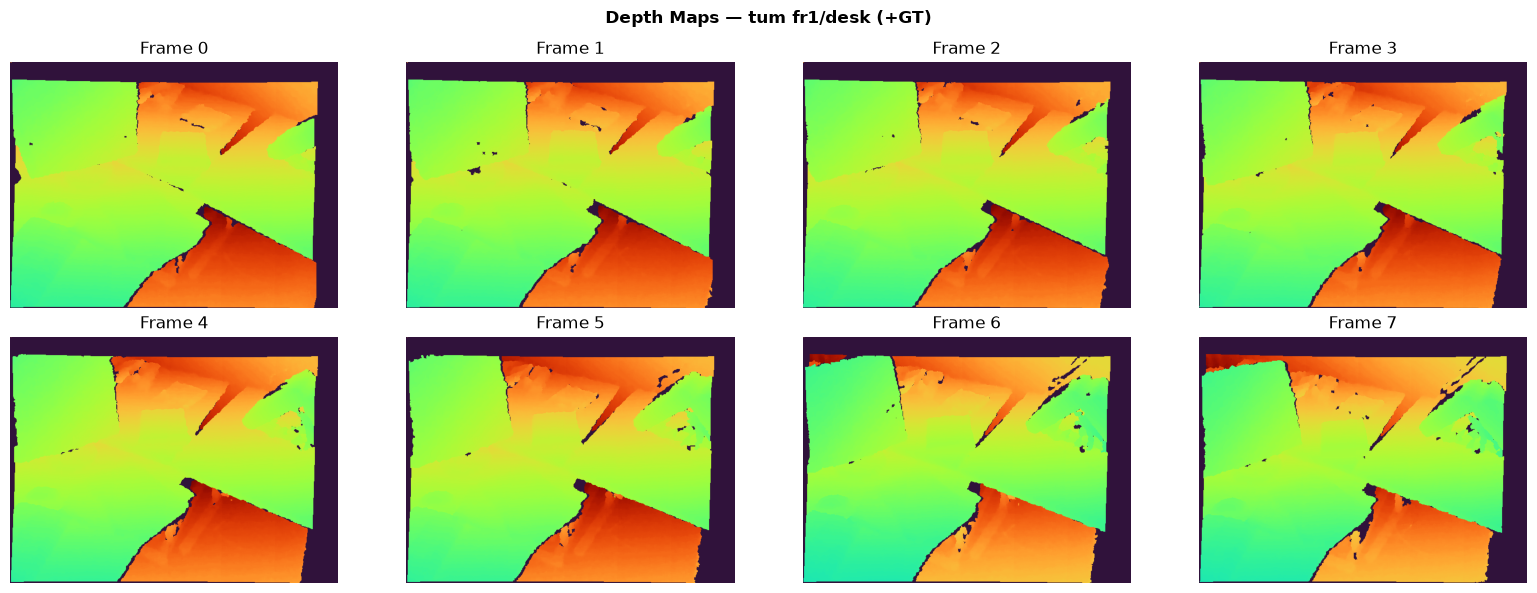

In [3]:
from src.pointcloud import depth_to_pointcloud
from src.transforms import se3_from_Rt


def render_synthetic_depth(K, T_cam, room_size=4.0):
    """Render depth by ray-casting into a box room."""
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    H_img, W_img = 240, 320
    depth = np.full((H_img, W_img), np.inf, dtype=np.float64)

    R, t = T_cam[:3, :3], T_cam[:3, 3]

    for v in range(H_img):
        for u in range(0, W_img, 2):  # subsample for speed
            ray_cam = np.array([(u - cx) / fx, (v - cy) / fy, 1.0])
            ray_world = R @ ray_cam

            min_t = np.inf
            half = room_size / 2
            for axis in range(3):
                for sign in [-1, 1]:
                    plane_val = sign * half
                    if abs(ray_world[axis]) > 1e-8:
                        t_hit = (plane_val - t[axis]) / ray_world[axis]
                        if t_hit > 0.1:
                            hit_point = t + t_hit * ray_world
                            other_axes = [a for a in range(3) if a != axis]
                            if (
                                all(
                                    abs(hit_point[a]) <= half + 0.01 for a in other_axes
                                )
                                and t_hit < min_t
                            ):
                                min_t = t_hit

            if min_t < np.inf:
                depth[v, u] = min_t
                if u + 1 < W_img:
                    depth[v, u + 1] = min_t

    depth[depth == np.inf] = 0
    return depth.astype(np.float32)


if pipeline_data is not None:
    K = pipeline_data["K"]
    H, W = pipeline_data["H"], pipeline_data["W"]
    depths = pipeline_data["depths"]
    gt_poses = pipeline_data["gt_poses"]
    n_frames = len(depths)
    depth_title = f"Depth Maps — {pipeline_data['source']}"
    print(f"Loaded {n_frames} frames from {pipeline_data['source']}")
else:
    print("No real datasets found — using synthetic room (see data/download.sh).")

    fx, fy = 300, 300
    cx, cy = 160, 120
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
    H, W = 240, 320

    n_frames = 20
    radius = 3.0
    gt_poses = []
    for i in range(n_frames):
        angle = 2 * np.pi * i / n_frames
        tx = radius * np.cos(angle)
        ty = 0.0
        tz = radius * np.sin(angle)

        forward = -np.array([tx, ty, tz])
        forward = forward / np.linalg.norm(forward)
        right = np.cross(np.array([0, 1, 0]), forward)
        right = right / np.linalg.norm(right)
        up = np.cross(forward, right)

        R = np.stack([right, up, forward], axis=1)
        t = np.array([tx, ty, tz])
        gt_poses.append(se3_from_Rt(R, t))

    print("Rendering synthetic depth maps...")
    depths = []
    for i in range(min(n_frames, 8)):
        depths.append(render_synthetic_depth(K, gt_poses[i]))
    depth_title = "Synthetic Depth Maps from Moving Camera"

# Visualize depth frames
n_show = min(len(depths), 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, (ax, d) in enumerate(zip(axes.flat, depths[:n_show], strict=False)):
    ax.imshow(d, cmap="turbo")
    ax.set_title(f"Frame {i}")
    ax.axis("off")
for ax in axes.flat[n_show:]:
    ax.axis("off")
plt.suptitle(depth_title, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. TSDF Integration

The Truncated Signed Distance Function (Curless & Levoy, SIGGRAPH 1996) stores, at each
voxel \(\mathbf{v}\), a running weighted average of the signed distance to the nearest surface:

$$D_k(\mathbf{v}) = \frac{W_{k-1}(\mathbf{v})\,D_{k-1}(\mathbf{v}) + w_k\,d_k(\mathbf{v})}{W_{k-1}(\mathbf{v}) + w_k}, \qquad
  W_k(\mathbf{v}) = W_{k-1}(\mathbf{v}) + w_k$$

where \(d_k(\mathbf{v}) = \text{clamp}\!\bigl(\|\mathbf{v} - \mathbf{o}\| - D(\pi(\mathbf{v})),\; -\mu,\; \mu\bigr)\)
is the truncated signed distance from depth frame \(k\), \(\mu\) is the truncation margin, and \(w_k\)
is the per-observation weight (typically \(w_k = \cos\theta / z^2\) for a ray with incidence angle \(\theta\)
at depth \(z\)).

**Why TSDF?**  The weighted-average update is *commutative* — frames can be integrated in any
order and the result converges to the same surface.  The zero-crossing of \(D(\mathbf{v})\)
defines the isosurface, which is extracted via **Marching Cubes** (Lorensen & Cline, 1987).

Fuse all depth frames into a single consistent 3D volume using
the TSDF (Curless & Levoy 1996) from Notebook 12.

Integrating depth frames into TSDF...
  Frame 0: integrated (255190 valid pixels)
  Frame 1: integrated (254610 valid pixels)
  Frame 2: integrated (253986 valid pixels)
  Frame 3: integrated (252930 valid pixels)
  Frame 4: integrated (252417 valid pixels)
  Frame 5: integrated (251141 valid pixels)
  Frame 6: integrated (250249 valid pixels)
  Frame 7: integrated (249708 valid pixels)

Extracted 347 points near TSDF zero-crossing
Extracted mesh: 317 vertices, 477 faces


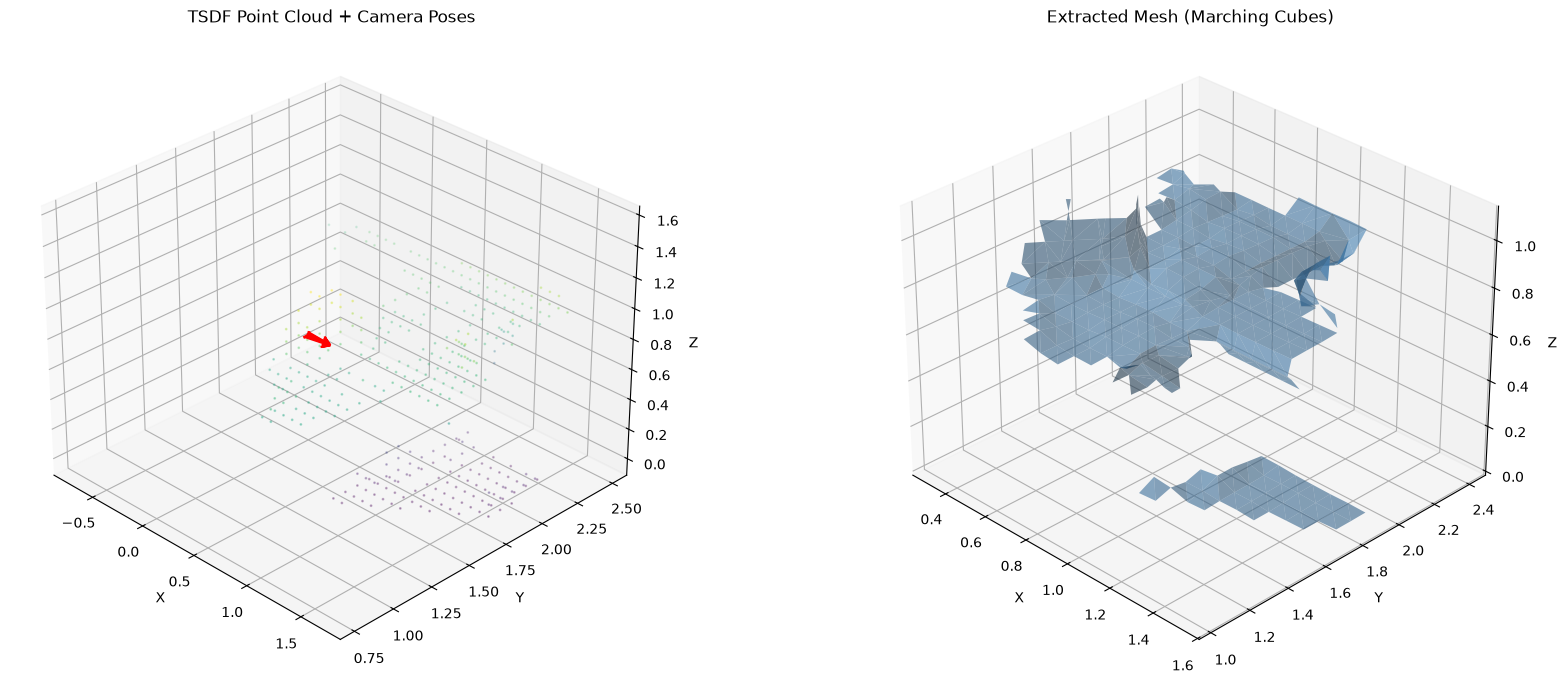

In [4]:
from src.tsdf import TSDFVolume

# Initialize TSDF volume covering the room
vol_bounds = np.array([[-3, 3], [-3, 3], [-3, 3]], dtype=np.float64)
tsdf = TSDFVolume(vol_bounds, voxel_size=0.08, trunc_dist=0.24)

# Integrate all depth frames
print("Integrating depth frames into TSDF...")
for i, (depth, pose) in enumerate(zip(depths, gt_poses[: len(depths)], strict=False)):
    tsdf.integrate(depth, K, pose)
    print(f"  Frame {i}: integrated ({(depth > 0).sum()} valid pixels)")

# Extract point cloud
pts = tsdf.get_point_cloud()
print(f"\nExtracted {len(pts)} points near TSDF zero-crossing")

# Extract mesh
verts, faces, norms, colors = tsdf.extract_mesh()
print(f"Extracted mesh: {len(verts)} vertices, {len(faces)} faces")

# Visualize — rich 3D dashboard
fig = plt.figure(figsize=(18, 7))

ax1 = fig.add_subplot(121, projection="3d")
if len(pts) > 0:
    sub = np.random.choice(len(pts), min(5000, len(pts)), replace=False)
    z_norm = (pts[sub, 2] - pts[sub, 2].min()) / max(np.ptp(pts[sub, 2]), 1e-6)
    ax1.scatter(
        pts[sub, 0], pts[sub, 1], pts[sub, 2], s=1, c=z_norm, cmap="viridis", alpha=0.6
    )

# Draw camera trajectory and frustums
cam_positions = np.array([pose[:3, 3] for pose in gt_poses[: len(depths)]])
ax1.plot(
    cam_positions[:, 0],
    cam_positions[:, 1],
    cam_positions[:, 2],
    "r-",
    lw=2,
    label="Camera trajectory",
)
for _i, pose in enumerate(gt_poses[: len(depths)]):
    pos = pose[:3, 3]
    fwd = pose[:3, 2] * 0.3
    ax1.quiver(
        pos[0],
        pos[1],
        pos[2],
        fwd[0],
        fwd[1],
        fwd[2],
        color="red",
        arrow_length_ratio=0.3,
        linewidth=1.5,
    )

ax1.set_title("TSDF Point Cloud + Camera Poses")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.view_init(elev=30, azim=-45)

ax2 = fig.add_subplot(122, projection="3d")
if len(verts) > 0:
    ax2.plot_trisurf(
        verts[:, 0],
        verts[:, 1],
        verts[:, 2],
        triangles=faces,
        alpha=0.6,
        color="steelblue",
    )
ax2.set_title("Extracted Mesh (Marching Cubes)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.view_init(elev=30, azim=-45)

plt.tight_layout()
plt.show()

---
## 3. Evaluation — Measuring What Matters

In 3D reconstruction, we distinguish two kinds of error:

**Trajectory accuracy** — how well did we estimate the camera path?
- **ATE (Absolute Trajectory Error)**: align estimated and ground-truth trajectories
  via Umeyama's Sim(3) alignment, then compute RMSE of position differences.
  $$\text{ATE}_\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^N \|\mathbf{p}_i^{\text{est}} - \mathbf{p}_i^{\text{gt}}\|^2}$$
- **RPE (Relative Pose Error)**: measures *local* drift over fixed-length segments.

**Map accuracy** — how close is the reconstructed surface to reality?
- **Completion** (recall): fraction of GT surface within \(\tau\) of reconstruction
- **Accuracy** (precision): fraction of reconstruction within \(\tau\) of GT surface
- **F-score** \(F_\tau\): harmonic mean of completion and accuracy at threshold \(\tau\)

For this demo, we add synthetic noise to GT poses and measure ATE — in
a real system, the VO/SLAM module would produce these poses.

In [5]:
# Evaluate trajectory (here we used GT poses, so error should be ~0)
from src.eval import compute_ate

# Simulate noisy pose estimates
noisy_poses = []
for p in gt_poses[: len(depths)]:
    p_noisy = p.copy()
    p_noisy[:3, 3] += np.random.normal(0, 0.02, 3)  # 2cm noise
    noisy_poses.append(p_noisy)

ate_rmse, ate_mean, ate_median, aligned, scale_err = compute_ate(
    noisy_poses, gt_poses[: len(depths)]
)
print("Trajectory evaluation:")
print(f"  ATE RMSE:   {ate_rmse:.4f} m")
print(f"  ATE Mean:   {ate_mean:.4f} m")
print(f"  ATE Median: {ate_median:.4f} m")

Trajectory evaluation:
  ATE RMSE:   0.0180 m
  ATE Mean:   0.0171 m
  ATE Median: 0.0151 m


---
## 4. Occupancy Grid Integration

The occupancy grid is the bridge between **perception** and **planning** — it
provides the binary free/occupied classification that path planners (A*, RRT*) require.

### Bayesian Occupancy Update

Each voxel stores a **log-odds** probability of being occupied:

$$l(\mathbf{v}) = \log\frac{p(\mathbf{v} = \text{occ})}{1 - p(\mathbf{v} = \text{occ})}$$

The log-odds form converts Bayesian updates into simple addition:

$$l_{k}(\mathbf{v}) = l_{k-1}(\mathbf{v}) + \underbrace{\log\frac{p(z_k \mid m = \text{occ})}{p(z_k \mid m = \text{free})}}_{\text{inverse sensor model}} - l_0$$

where \(l_0 = \log\frac{p_0}{1 - p_0}\) is the prior log-odds (typically \(l_0 = 0\) for \(p_0 = 0.5\)).

### Inverse Sensor Model

For a depth sensor observing depth \(z\) at pixel \((u,v)\):
- Voxels **along the ray** at distance \(< z - \epsilon\): update as **free** (\(\Delta l < 0\))
- Voxels **near the surface** at distance \(\approx z\): update as **occupied** (\(\Delta l > 0\))
- Voxels **behind the surface** at distance \(> z + \epsilon\): no update (unobserved)

This ray-casting approach (Elfes, 1989; Hornung et al., 2013) naturally handles sensor noise
and produces probabilistic maps that are robust to individual measurement errors.

Integrating into occupancy grid...
  Frame 0: integrated
  Frame 1: integrated
  Frame 2: integrated


  Frame 3: integrated
  Frame 4: integrated
  Frame 5: integrated
  Frame 6: integrated


  Frame 7: integrated

Occupied voxels: 193
Free voxels:     339


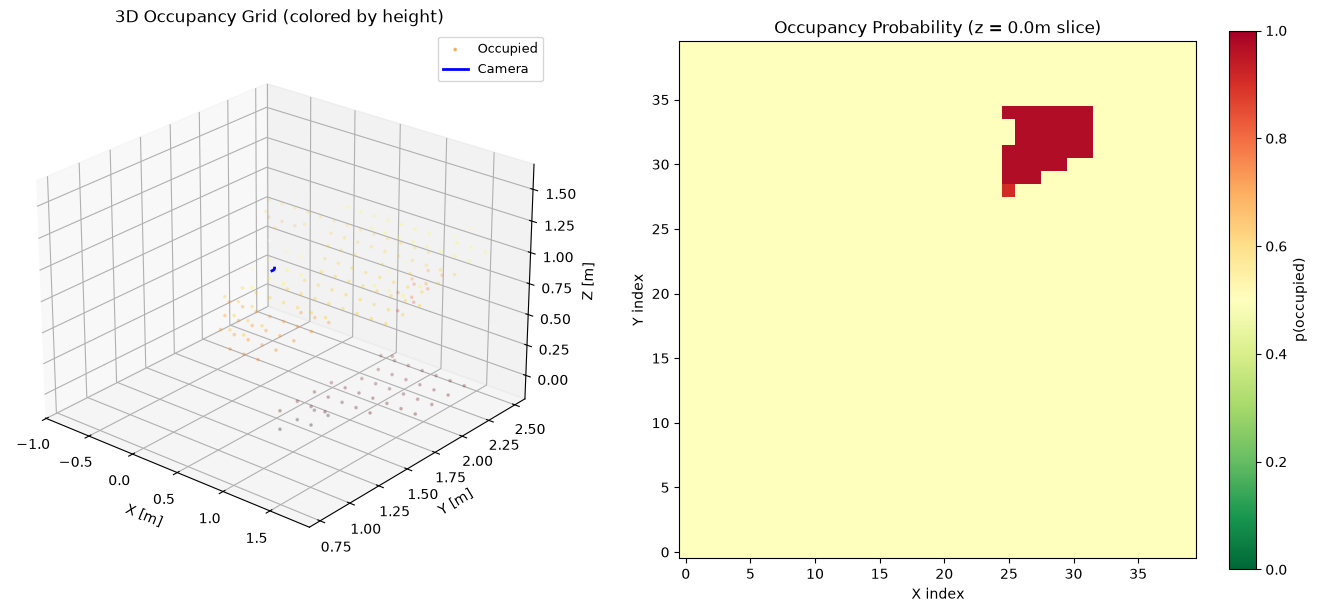

In [6]:
from src.occupancy import OccupancyGrid

# Initialize occupancy grid
occ_bounds = np.array([[-3, 3], [-3, 3], [-3, 3]], dtype=np.float64)
occ_grid = OccupancyGrid(occ_bounds, resolution=0.15)

# Integrate depth frames
print("Integrating into occupancy grid...")
for i, (depth, pose) in enumerate(zip(depths, gt_poses[: len(depths)], strict=False)):
    occ_grid.update(depth, K, pose)
    print(f"  Frame {i}: integrated")

# Extract occupied and free points
occupied = occ_grid.get_occupied_points(threshold=0.6)
free = occ_grid.get_free_points(threshold=0.4)

print(f"\nOccupied voxels: {len(occupied)}")
print(f"Free voxels:     {len(free)}")

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
if len(occupied) > 0:
    sub = np.random.choice(len(occupied), min(3000, len(occupied)), replace=False)
    occ_heights = occupied[sub, 2]
    ax1.scatter(
        occupied[sub, 0],
        occupied[sub, 1],
        occ_heights,
        s=3,
        c=occ_heights,
        cmap="hot",
        alpha=0.5,
        label="Occupied",
    )
if len(free) > 0:
    sub_f = np.random.choice(len(free), min(500, len(free)), replace=False)
    ax1.scatter(
        free[sub_f, 0], free[sub_f, 1], free[sub_f, 2], s=1, c="lightgreen", alpha=0.05
    )

# Overlay camera trajectory
cam_pos = np.array([p[:3, 3] for p in gt_poses[: len(depths)]])
ax1.plot(cam_pos[:, 0], cam_pos[:, 1], cam_pos[:, 2], "b-", lw=2, label="Camera")

ax1.set_title("3D Occupancy Grid (colored by height)")
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.set_zlabel("Z [m]")
ax1.view_init(elev=25, azim=-50)
ax1.legend(fontsize=9)

# Show probability cross-section
prob = occ_grid.to_probability()
mid_z = prob.shape[2] // 2
ax2 = fig.add_subplot(122)
im = ax2.imshow(prob[:, :, mid_z].T, origin="lower", cmap="RdYlGn_r", vmin=0, vmax=1)
ax2.set_title(f"Occupancy Probability (z = {mid_z * 0.15 - 3:.1f}m slice)")
ax2.set_xlabel("X index")
ax2.set_ylabel("Y index")
plt.colorbar(im, ax=ax2, label="p(occupied)")

plt.tight_layout()
plt.show()

---
## 5. TSDF vs Occupancy Grid — When to Use Which

Choosing the right volumetric representation is a **system-level decision** that depends
on the downstream task.  Both representations discretise the workspace into voxels and integrate
depth frames incrementally, but the stored quantity and update rule differ fundamentally.

| Property | TSDF Volume | Occupancy Grid |
|----------|-------------|----------------|
| **Stores** | Signed distance \(d\) + weight \(w\) | Log-odds \(l = \log\frac{p}{1-p}\) |
| **Update rule** | Weighted running average (commutative) | Log-odds addition: \(l_k = l_{k-1} + \Delta l\) |
| **Surface** | Zero-crossing \(\{v : D(v) = 0\}\) | Threshold \(\{v : p(v) > \tau\}\) |
| **Best for** | Dense surface reconstruction, meshing | Path planning, free-space queries |
| **Mesh extraction** | Marching Cubes (Lorensen & Cline 1987) | Voxel boundary extraction |
| **Handles moving objects** | Poorly (weighted average remembers old data) | Well (log-odds has bounded memory via clamping) |
| **Memory** | 2 floats/voxel (distance + weight) | 1 float/voxel (log-odds) |

**Key insight**: for autonomous drone navigation, you typically need *both* — a TSDF for
visualisation and inspection, and an occupancy grid for A* / RRT* path planning with a binary
free/occupied classification.

### Mathematical comparison of update rules

**TSDF** (associative, order-independent):
$$D^+ = \frac{W \cdot D + w \cdot d}{W + w}, \quad W^+ = W + w$$

**Log-odds occupancy** (additive, easy to "forget" with clamping):
$$l^+ = \operatorname{clamp}\!\bigl(l + \Delta l,\; l_{\min},\; l_{\max}\bigr), \quad
\Delta l = \log\frac{p(z|m)}{1 - p(z|m)}$$

The log-odds form avoids the numerical issues of multiplying many probabilities near 0 or 1
and naturally supports sensor-model tuning via the *inverse sensor model* \(p(z|m)\).

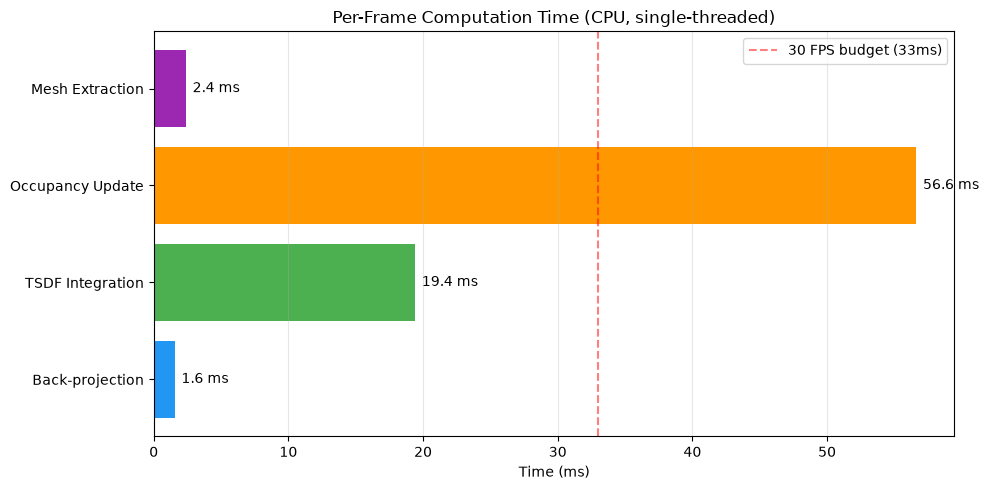

Total per-frame (back-proj + TSDF + occ): 77.6 ms
Achievable FPS (map update only): 12.9
Mesh extraction (once): 2.4 ms

Note: These are CPU times. GPU acceleration (CUDA/numba) would be ~10-50× faster.


In [7]:
# Computational Profiling: Time each component per frame

import time

# Profile TSDF integration
tsdf_profile = TSDFVolume(vol_bounds, voxel_size=0.08, trunc_dist=0.24)
times_tsdf = []
for depth, pose in zip(depths, gt_poses[: len(depths)], strict=False):
    t0 = time.perf_counter()
    tsdf_profile.integrate(depth, K, pose)
    times_tsdf.append(time.perf_counter() - t0)

# Profile occupancy grid integration
occ_profile = OccupancyGrid(occ_bounds, resolution=0.15)
times_occ = []
for depth, pose in zip(depths, gt_poses[: len(depths)], strict=False):
    t0 = time.perf_counter()
    occ_profile.update(depth, K, pose)
    times_occ.append(time.perf_counter() - t0)

# Profile depth-to-pointcloud
times_pc = []
for depth in depths:
    t0 = time.perf_counter()
    depth_to_pointcloud(depth, K)
    times_pc.append(time.perf_counter() - t0)

# Profile mesh extraction
t0 = time.perf_counter()
verts_p, faces_p, _, _ = tsdf_profile.extract_mesh()
time_mesh = time.perf_counter() - t0

# Visualise
components = [
    "Back-projection",
    "TSDF Integration",
    "Occupancy Update",
    "Mesh Extraction",
]
avg_times = [
    np.mean(times_pc) * 1000,
    np.mean(times_tsdf) * 1000,
    np.mean(times_occ) * 1000,
    time_mesh * 1000,
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    components, avg_times, color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
)
ax.set_xlabel("Time (ms)")
ax.set_title("Per-Frame Computation Time (CPU, single-threaded)")
for bar, t in zip(bars, avg_times, strict=False):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{t:.1f} ms",
        va="center",
    )
ax.axvline(x=33, color="red", linestyle="--", alpha=0.5, label="30 FPS budget (33ms)")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

total_per_frame = np.mean(times_pc) + np.mean(times_tsdf) + np.mean(times_occ)
print(f"Total per-frame (back-proj + TSDF + occ): {total_per_frame * 1000:.1f} ms")
print(f"Achievable FPS (map update only): {1 / total_per_frame:.1f}")
print(f"Mesh extraction (once): {time_mesh * 1000:.1f} ms")
print(
    "\nNote: These are CPU times. GPU acceleration (CUDA/numba) would be ~10-50× faster."
)

---
## 5b. Error Propagation Through the Pipeline

Understanding how errors cascade is critical for system design.  Each stage
amplifies upstream errors:

### Depth Error → Map Error

A depth measurement error \(\delta z\) at pixel \((u, v)\) produces a 3D point error:

$$\delta X = \frac{u - c_x}{f_x} \delta z, \quad
\delta Y = \frac{v - c_y}{f_y} \delta z, \quad
\delta Z = \delta z$$

At the image edge (\(u - c_x \approx W/2\)), the lateral error is
\(\delta X \approx \frac{W}{2 f_x} \delta z\).  For a VGA camera with
\(f_x = 500\), \(W = 640\): \(\frac{320}{500} \times 5\,\text{cm} = 3.2\,\text{cm}\) — a 5 cm depth error at 3 m produces a 3.2 cm lateral error.

### Pose Error → Map Error

A rotation error \(\delta\theta\) at distance \(d\) from the camera produces:

$$\delta p = d \cdot \delta\theta \quad \text{(small angle)}$$

At \(d = 5\) m, a 1° rotation error produces a **8.7 cm** map error — this is why
accurate pose estimation (BA, VIO) is more important than raw depth accuracy.

### The Error Budget Rule of Thumb

| Source | Typical magnitude | Impact on map at 5 m |
|--------|-------------------|---------------------|
| Depth noise (stereo) | ~2 cm | 2 cm along ray |
| Depth noise (monocular NN) | ~15 cm | 15 cm along ray |
| Pose translation error | ~3 cm | 3 cm everywhere |
| Pose rotation error | ~0.5° | 4.4 cm at 5 m |
| **Total (stereo + VIO)** | — | **~6 cm RMS** |
| **Total (mono NN + VO)** | — | **~18 cm RMS** |

This is why production systems prefer stereo or RGB-D cameras over monocular
depth estimation — the error budget is 3× tighter.

---
## 6. Path Planning on 3D Occupancy Maps

The bridge from **perception** to **action**: we've built a 3D occupancy map —
now the drone needs to plan a collision-free path through it.

### 6.1 A* on Voxel Grids

Discretise space into a 3D grid (which our occupancy grid already is).
Each occupied voxel is impassable. A* finds the shortest path from start to goal
through free voxels.

**Heuristic**: Euclidean distance (admissible + consistent).

**3D neighbourhood**: 26-connected grid (6 face + 12 edge + 8 corner neighbours).

**Cost**: distance + safety penalty near obstacles:

$$
g(n) = g(\text{parent}) + \| n - \text{parent} \| + \lambda \cdot \max\!\left(0,\, d_{\text{safe}} - d_{\text{obstacle}}(n)\right)
$$

### 6.2 RRT/RRT*

Rapidly-exploring Random Trees: sample random points in free space, grow a tree
toward them. **RRT*** rewires the tree to find asymptotically optimal paths.
Better for complex, high-dimensional configuration spaces.

### 6.3 Artificial Potential Fields (APF)

Treat the goal as an **attractor** (\(U_{\text{att}} = \frac{1}{2} k_a \| \mathbf{q} - \mathbf{q}_g \|^2\))
and obstacles as **repulsors** (\(U_{\text{rep}} = \frac{k_r}{2} \left(\frac{1}{d_{\text{obs}}} - \frac{1}{d_0}\right)^2\) when \(d_{\text{obs}} < d_0\)).

$$
\mathbf{F} = -\nabla U_{\text{att}} - \nabla U_{\text{rep}}
$$

Fast and reactive but prone to **local minima** (gets stuck in concavities).

### 6.4 A*-APF Hybrid (2026)

A* for **global** planning + adaptive APF for **local** smoothing.
Reduces path length by 15-25%, improves smoothness by 30-45%.

### 6.5 Trajectory Optimisation

Raw A*/RRT paths are kinematically infeasible (sharp corners, speed jumps).
Smooth them with **B-spline fitting** subject to velocity/acceleration/jerk
limits. The result: a trajectory the drone can actually fly.

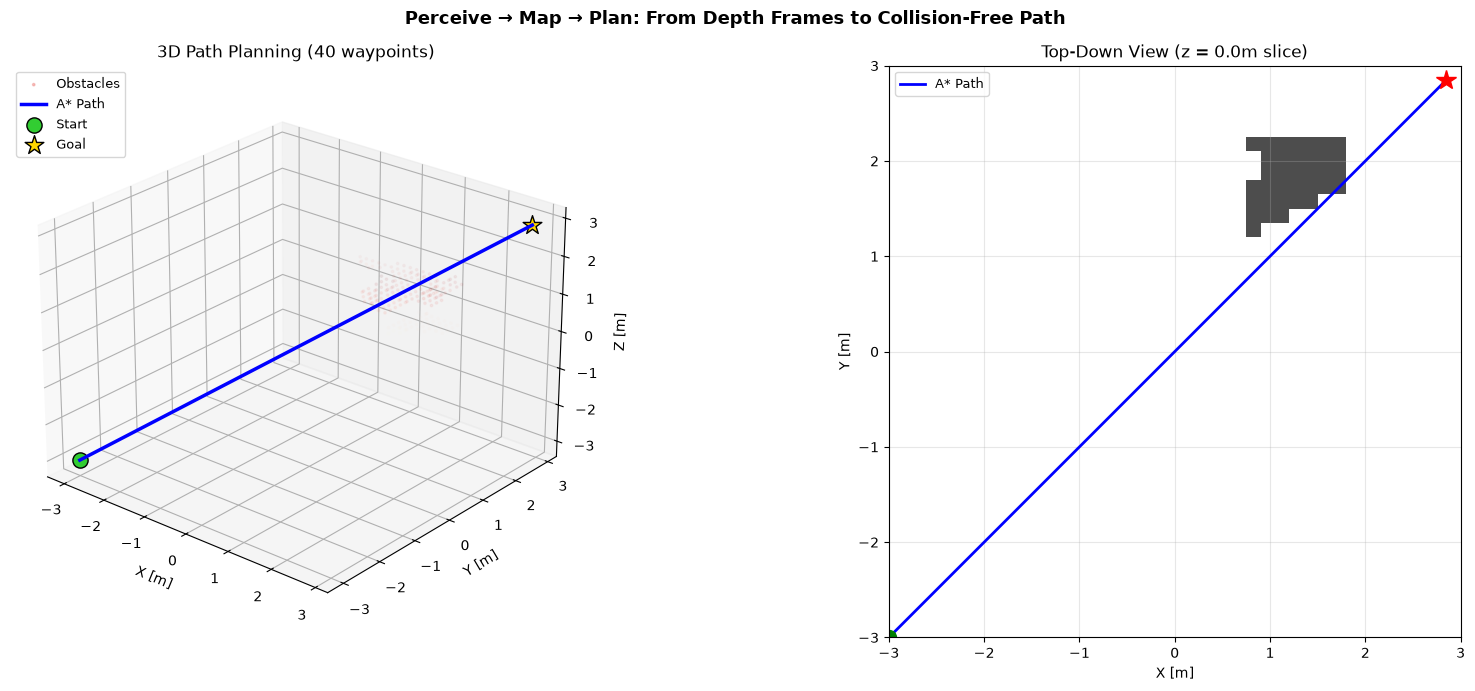

Path found: 40 waypoints
Path length: 10.13 m


In [8]:
import heapq


def astar_3d(grid, start, goal, safety_dist=2):
    """A* search on a 3D occupancy grid.

    grid: 3D boolean array (True = occupied)
    start, goal: (i, j, k) integer indices
    safety_dist: penalty ramp distance (in voxels)
    """
    shape = grid.shape

    from scipy.ndimage import distance_transform_edt

    dist_to_obs = np.asarray(
        distance_transform_edt(~grid, return_distances=True, return_indices=False)
    )

    def heuristic(a, b):
        return np.sqrt(sum((ai - bi) ** 2 for ai, bi in zip(a, b, strict=False)))

    def cost(pos):
        d = dist_to_obs[pos]
        safety_penalty = max(0, safety_dist - d) * 0.5
        return safety_penalty

    # 26-connected neighbours
    neighbours = []
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            for dk in [-1, 0, 1]:
                if di == 0 and dj == 0 and dk == 0:
                    continue
                neighbours.append((di, dj, dk, np.sqrt(di**2 + dj**2 + dk**2)))

    open_set = [(0 + heuristic(start, goal), 0, start)]
    came_from = {}
    g_score = {start: 0}
    visited = set()

    while open_set:
        _, _g_curr, current = heapq.heappop(open_set)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        if current in visited:
            continue
        visited.add(current)

        for di, dj, dk, step_dist in neighbours:
            ni, nj, nk = current[0] + di, current[1] + dj, current[2] + dk
            npos = (ni, nj, nk)

            if not (0 <= ni < shape[0] and 0 <= nj < shape[1] and 0 <= nk < shape[2]):
                continue
            if grid[ni, nj, nk]:
                continue

            tentative_g = g_score[current] + step_dist + cost(npos)

            if npos not in g_score or tentative_g < g_score[npos]:
                g_score[npos] = tentative_g
                f = tentative_g + heuristic(npos, goal)
                heapq.heappush(open_set, (f, tentative_g, npos))
                came_from[npos] = current

    return None  # no path found


# Demo: plan a path through the occupancy grid
if len(occupied) > 0:
    occ_vol = occ_grid.to_probability() > 0.6

    # Find valid start and goal (free voxels)
    free_indices = np.argwhere(~occ_vol)
    if len(free_indices) > 10:
        start_idx = tuple(free_indices[0])
        goal_idx = tuple(free_indices[-1])

        path = astar_3d(occ_vol, start_idx, goal_idx)

        if path is not None:
            path_arr = np.array(path)
            # Convert indices to world coordinates
            res = occ_grid.resolution
            origin = occ_bounds[:, 0]
            path_world = path_arr * res + origin

            fig = plt.figure(figsize=(18, 7))

            # --- 3D view with obstacles and path ---
            ax1 = fig.add_subplot(121, projection="3d")
            if len(occupied) > 0:
                sub_occ = np.random.choice(
                    len(occupied), min(1500, len(occupied)), replace=False
                )
                occ_z = occupied[sub_occ, 2]
                ax1.scatter(
                    occupied[sub_occ, 0],
                    occupied[sub_occ, 1],
                    occ_z,
                    s=3,
                    c=occ_z,
                    cmap="Reds",
                    alpha=0.25,
                    label="Obstacles",
                )

            ax1.plot(
                path_world[:, 0],
                path_world[:, 1],
                path_world[:, 2],
                "b-",
                linewidth=2.5,
                label="A* Path",
                zorder=5,
            )
            ax1.scatter(
                *path_world[0],
                c="limegreen",
                s=120,
                marker="o",
                edgecolors="k",
                zorder=10,
                label="Start",
            )
            ax1.scatter(
                *path_world[-1],
                c="gold",
                s=200,
                marker="*",
                edgecolors="k",
                zorder=10,
                label="Goal",
            )

            ax1.set_title(f"3D Path Planning ({len(path)} waypoints)", fontsize=12)
            ax1.set_xlabel("X [m]")
            ax1.set_ylabel("Y [m]")
            ax1.set_zlabel("Z [m]")
            ax1.view_init(elev=25, azim=-50)
            ax1.legend(fontsize=9, loc="upper left")

            # --- Top-down 2D slice ---
            ax2 = fig.add_subplot(122)
            mid_z = occ_vol.shape[2] // 2
            ax2.imshow(
                occ_vol[:, :, mid_z].T,
                origin="lower",
                cmap="Greys",
                alpha=0.7,
                extent=(
                    origin[0],
                    origin[0] + occ_vol.shape[0] * res,
                    origin[1],
                    origin[1] + occ_vol.shape[1] * res,
                ),
            )
            ax2.plot(path_world[:, 0], path_world[:, 1], "b-", lw=2, label="A* Path")
            ax2.plot(path_world[0, 0], path_world[0, 1], "go", ms=10)
            ax2.plot(path_world[-1, 0], path_world[-1, 1], "r*", ms=15)
            ax2.set_xlabel("X [m]")
            ax2.set_ylabel("Y [m]")
            ax2.set_title(
                f"Top-Down View (z = {mid_z * res + origin[2]:.1f}m slice)", fontsize=12
            )
            ax2.set_aspect("equal")
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.3)

            plt.suptitle(
                "Perceive → Map → Plan: From Depth Frames to Collision-Free Path",
                fontsize=13,
                fontweight="bold",
            )
            plt.tight_layout()
            plt.show()

            print(f"Path found: {len(path)} waypoints")
            print(
                f"Path length: {sum(np.linalg.norm(np.diff(path_world, axis=0), axis=1)):.2f} m"
            )
        else:
            print("No path found — start or goal may be enclosed.")
    else:
        print("Not enough free voxels for path planning demo.")
else:
    print("No occupied voxels — run occupancy integration first.")

---
## 7. Edge Deployment — Running Neural Nets on Drones

Deploying neural networks on a 10W power budget at 30 FPS is the make-or-break
challenge for vision-based autonomy.  The gap between "works on a workstation" and
"flies on a drone" is enormous.

### 7.1 The Deployment Pipeline

```
PyTorch Model → ONNX Export → TensorRT Engine → Drone Hardware
     (training)     (portability)   (optimisation)    (inference)
```

Each step applies specific optimisations:
- **ONNX** (Open Neural Network Exchange): portable IR; fuses operations like
  BatchNorm into preceding convolutions, removes training-only nodes
- **TensorRT**: NVIDIA's inference optimiser — kernel auto-tuning, layer fusion,
  memory planning, and precision calibration

### 7.2 Quantisation — Trading Bits for Speed

| Precision | Bits | Speedup | Depth RMSE impact | When to use |
|-----------|------|---------|-------------------|-------------|
| FP32 | 32 | 1× | Baseline | Development only |
| FP16 | 16 | ~2× | <1% degradation | **Default for deployment** |
| INT8 | 8 | ~4× | 3-8% degradation | Jetson Nano, tight latency |
| INT4 (W4A16) | 4/16 | ~6× | 10-15% degradation | Experimental (2026) |

**FP16** is the production standard — half the memory, double the throughput,
negligible quality loss.

**INT8** requires a **calibration dataset** (not random tensors!) to compute
activation histograms.  The calibrator minimises KL divergence between FP32 and INT8
output distributions.

### 7.3 Real Hardware Benchmarks (2025-2026)

| Model | Hardware | Resolution | FPS | Power | Precision |
|-------|----------|-----------|-----|-------|-----------|
| DA2-Small | Jetson Nano (10W) | 518×518 | 6.5 | 10W | FP16 TRT |
| DA2-Small | Jetson Orin (15W) | 308×308 | ~42 | 15W | FP16 TRT |
| DA3-Small | Jetson Orin Nano | 308×308 | 218 | 15W | FP16 TRT |
| cuVSLAM | Jetson Orin | 640×480 | 60+ | 15W | Mixed |
| VGGT-SLAM 2.0 | Jetson Thor (100W) | 640×480 | 15 | 100W | FP16 |
| ORB-SLAM3 | Jetson Orin | 640×480 | 30+ | CPU | — |

**Key insight** (egordmitriev.dev, May 2026): cuVSLAM has become the production
default for NVIDIA platforms.  Foundation-3D systems (VGGT-SLAM 2.0) are still
workstation-class for real-time use, but advancing rapidly.

### 7.4 The Latency Budget at 30 FPS

Each frame gets **33 ms** — this is a hard constraint for reactive obstacle avoidance.

| Component | Budget | Parallelisable? | Notes |
|-----------|--------|-----------------|-------|
| Depth estimation | ~15 ms | GPU | The bottleneck; pipeline with next frame |
| VO/VIO | ~5 ms | CPU + GPU | Feature-based is fast; VIO adds IMU fusion |
| TSDF/Occupancy fusion | ~3 ms | GPU | CUDA kernel; nearly free |
| Path planning | ~5 ms | CPU | Incremental A* or DWA |
| Control + actuators | ~2 ms | CPU | PID/SE(3) controller is O(1) |
| Overhead | ~3 ms | — | Data transfer, memory copies, sync |

### 7.5 Key Optimisation Techniques

1. **Layer fusion**: merge Conv → BN → ReLU into a single kernel
2. **Resolution reduction**: infer at 308×308 instead of 518×518 (4× fewer pixels)
3. **Model distillation**: train a small student from a large teacher (DA3-Small)
4. **Pipelining**: overlap frame \(k\) inference with frame \(k-1\) post-processing
5. **Dynamic batching**: batch multiple depth crops for stereo matching

## 8. Emerging Sensors & Sim-to-Real (Brief)

**Event cameras** are neuromorphic sensors where each pixel fires independently
when brightness changes. Key properties: μs temporal resolution, 120+ dB dynamic range,
no motion blur. ESVO2 (TRO 2025) and Stereo-DEVO achieve SOTA VIO with events.
Relevant when standard cameras fail (fast rotation, entering dark rooms).

**Sim-to-real**: bridge the domain gap via domain randomization (vary textures/lighting
in simulation) or domain adaptation (Gradient Reversal Layers). **DropD-SLAM** (2025)
replaces a physical depth sensor with Depth Anything V2 predictions fed into
unmodified RGB-D SLAM — 7.4 cm ATE on TUM at 22 FPS. Key finding: **temporal
consistency** of depth predictions matters more than per-frame accuracy for SLAM.

## 10. System Design Exercise

Given these three scenarios, design the optimal system configuration — justify
your choices of feature type, depth method, map representation, and sensor fusion.

### Scenario A: Indoor Inspection Drone
Stereo camera + IMU, 10×10 m room, needs obstacle avoidance.

### Scenario B: Outdoor Delivery Drone
Monocular camera + GPS, 500 m route, needs path planning.

### Scenario C: Handheld AR Device
RGB-D camera, needs real-time mesh for rendering.

In [9]:
# Design Exercise: Compare system configurations


configs = {
    "Scenario": ["A: Indoor Drone", "B: Delivery Drone", "C: AR Device"],
    "Features": [
        "ORB (fast, sufficient)",
        "SuperPoint+LightGlue (robust)",
        "ORB (real-time)",
    ],
    "Depth": [
        "Stereo SGBM (metric, reliable)",
        "DA2 mono + GPS scale",
        "RGB-D sensor (direct)",
    ],
    "Pose": ["Stereo VIO (ORB-SLAM3)", "Mono VO + GPS fusion", "RGB-D SLAM"],
    "Map": [
        "Occupancy Grid (planning)",
        "Sparse occupancy (memory)",
        "TSDF → Mesh (rendering)",
    ],
    "Loop Closure": [
        "Yes (revisit rooms)",
        "No (one-way route)",
        "Yes (AR persistence)",
    ],
    "FPS Target": ["30 (obstacle avoidance)", "10 (path planning)", "30 (smooth AR)"],
    "Key Challenge": [
        "Textureless walls → stereo fails, need IMU",
        "Scale ambiguity → GPS provides scale",
        "Mesh quality → needs dense depth + good fusion",
    ],
}

# Print as formatted table
for key in configs:
    if key == "Scenario":
        print(
            f"{'':20s} | {configs['Scenario'][0]:30s} | {configs['Scenario'][1]:30s} | {configs['Scenario'][2]:30s}"
        )
        print("-" * 120)
    else:
        print(
            f"{key:20s} | {configs[key][0]:30s} | {configs[key][1]:30s} | {configs[key][2]:30s}"
        )

print("\n--- Justification ---")
print("""
Scenario A (Indoor Drone):
  - Stereo gives METRIC depth — no scale ambiguity for obstacle avoidance
  - IMU essential: textureless corridors cause VO failures
  - Occupancy grid stores free/occupied/unknown — perfect for A* planning
  - Loop closure critical: drone revisits rooms, must keep consistent map

Scenario B (Delivery Drone):
  - Monocular + GPS: GPS gives absolute position (outdoors), mono gives obstacle awareness
  - DA2 depth is relative but sufficient for obstacle distance ranking
  - Sparse map: 500m route doesn't need dense reconstruction
  - No loop closure: linear route, won't revisit locations

Scenario C (AR Device):
  - RGB-D sensor provides metric depth directly (no estimation needed)
  - TSDF → Marching Cubes → Mesh: the standard AR pipeline (ARKit uses this)
  - 30 FPS mandatory for smooth AR overlay
  - Loop closure enables "persistent AR" — place virtual objects, come back later
""")

                     | A: Indoor Drone                | B: Delivery Drone              | C: AR Device                  
------------------------------------------------------------------------------------------------------------------------
Features             | ORB (fast, sufficient)         | SuperPoint+LightGlue (robust)  | ORB (real-time)               
Depth                | Stereo SGBM (metric, reliable) | DA2 mono + GPS scale           | RGB-D sensor (direct)         
Pose                 | Stereo VIO (ORB-SLAM3)         | Mono VO + GPS fusion           | RGB-D SLAM                    
Map                  | Occupancy Grid (planning)      | Sparse occupancy (memory)      | TSDF → Mesh (rendering)       
Loop Closure         | Yes (revisit rooms)            | No (one-way route)             | Yes (AR persistence)          
FPS Target           | 30 (obstacle avoidance)        | 10 (path planning)             | 30 (smooth AR)                
Key Challenge        | Textureless wall

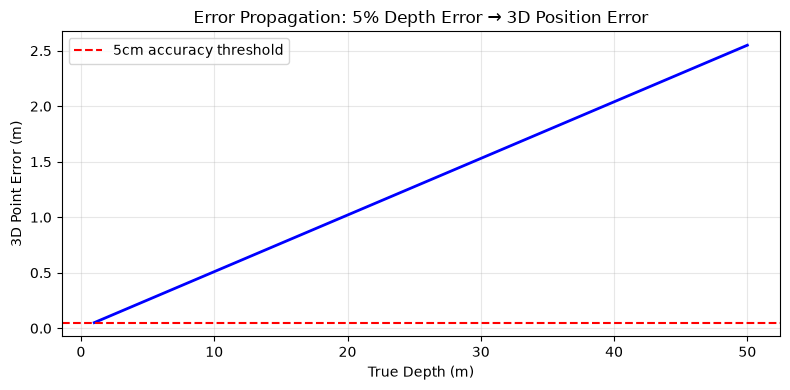

Max usable depth for 5cm accuracy: 1.0 m
✓ Error propagation analysis correct


In [10]:
from typing import TypedDict

import matplotlib.pyplot as plt
import numpy as np


class DepthErrorResult(TypedDict):
    """Back-projection results for a single pixel and depth."""

    point_true: np.ndarray
    point_noisy: np.ndarray
    error_3d: float


def propagate_depth_error(
    K: np.ndarray, depth: float, pixel: np.ndarray, depth_error_pct: float = 0.05
) -> DepthErrorResult:
    """Compute how depth estimation error propagates to 3D point error.

    Parameters
    ----------
    K : (3, 3) array
        Camera intrinsic matrix.
    depth : float
        True depth (meters).
    pixel : (2,) array
        Pixel coordinates (u, v).
    depth_error_pct : float
        Relative depth error (e.g. 0.05 = 5%).

    Returns
    -------
    result : dict
        'point_true': (3,) true 3D point,
        'point_noisy': (3,) noisy 3D point,
        'error_3d': float, Euclidean error in meters.
    """
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    u, v = pixel

    # True back-projection
    X = (u - cx) * depth / fx
    Y = (v - cy) * depth / fy
    Z = depth
    point_true = np.array([X, Y, Z])

    # Noisy back-projection
    depth_noisy = depth * (1 + depth_error_pct)
    X_n = (u - cx) * depth_noisy / fx
    Y_n = (v - cy) * depth_noisy / fy
    Z_n = depth_noisy
    point_noisy = np.array([X_n, Y_n, Z_n])

    error_3d = float(np.linalg.norm(point_true - point_noisy))
    return {"point_true": point_true, "point_noisy": point_noisy, "error_3d": error_3d}


# Sweep depth from 1m to 50m with 5% error
K = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]], dtype=np.float64)
pixel = np.array([400.0, 300.0])  # off-center pixel

depths = np.linspace(1, 50, 50)
errors = [propagate_depth_error(K, d, pixel, 0.05)["error_3d"] for d in depths]

plt.figure(figsize=(8, 4))
plt.plot(depths, errors, "b-", linewidth=2)
plt.axhline(y=0.05, color="r", linestyle="--", label="5cm accuracy threshold")
plt.xlabel("True Depth (m)")
plt.ylabel("3D Point Error (m)")
plt.title("Error Propagation: 5% Depth Error → 3D Position Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find max usable depth for 5cm accuracy
max_depth_5cm = depths[np.searchsorted(errors, 0.05)]
print(f"Max usable depth for 5cm accuracy: {max_depth_5cm:.1f} m")

# Verification
assert errors[0] < errors[-1], "Error should increase with depth"
assert propagate_depth_error(K, 1.0, pixel, 0.0)["error_3d"] < 1e-10, (
    "Zero error at 0% noise"
)
print("✓ Error propagation analysis correct")

In [11]:
import numpy as np


def compute_latency_budget(
    velocity_ms: float, min_detection_range_m: float, safety_factor: float = 2.0
) -> dict[str, float]:
    """Compute the maximum allowable pipeline latency.

    The drone must detect and react to an obstacle at `min_detection_range_m`.
    The total reaction time = perception + planning + actuation.
    We budget 60% of the time to perception.

    Parameters
    ----------
    velocity_ms : float
        Drone velocity in m/s.
    min_detection_range_m : float
        Minimum range at which obstacle must be detected.
    safety_factor : float
        Multiply velocity for worst-case braking distance.

    Returns
    -------
    budget : dict
        'total_time_ms': total time budget (ms),
        'perception_ms': perception budget (ms),
        'planning_ms': planning budget (ms),
        'actuation_ms': actuation budget (ms),
        'fps_required': minimum frames per second.
    """
    if velocity_ms <= 0:
        raise ValueError("velocity must be positive")

    # Time to traverse the detection range
    total_time_s = min_detection_range_m / (velocity_ms * safety_factor)
    total_time_ms = total_time_s * 1000

    # Budget: 60% perception, 25% planning, 15% actuation
    perception_ms = total_time_ms * 0.60
    planning_ms = total_time_ms * 0.25
    actuation_ms = total_time_ms * 0.15
    fps_required = 1000.0 / perception_ms

    return {
        "total_time_ms": total_time_ms,
        "perception_ms": perception_ms,
        "planning_ms": planning_ms,
        "actuation_ms": actuation_ms,
        "fps_required": fps_required,
    }


# Compare budgets for different flight regimes
scenarios = [
    ("Slow indoor", 1.0, 3.0),
    ("Medium indoor", 3.0, 5.0),
    ("Fast outdoor", 10.0, 15.0),
    ("Racing drone", 20.0, 30.0),
]

print(f"{'Scenario':<18} {'Total (ms)':>10} {'Percept (ms)':>12} {'FPS':>6}")
print("-" * 50)
for name, vel, det_range in scenarios:
    b = compute_latency_budget(vel, det_range)
    print(
        f"{name:<18} {b['total_time_ms']:>10.0f} {b['perception_ms']:>12.0f} {b['fps_required']:>6.1f}"
    )

# Verification
b_slow = compute_latency_budget(1.0, 3.0)
b_fast = compute_latency_budget(10.0, 15.0)
assert b_slow["perception_ms"] > b_fast["perception_ms"], (
    "Slower drone should have more budget"
)
assert b_fast["fps_required"] > b_slow["fps_required"], "Faster drone needs higher FPS"
print("\n✓ Latency budget analysis correct")

Scenario           Total (ms) Percept (ms)    FPS
--------------------------------------------------
Slow indoor              1500          900    1.1
Medium indoor             833          500    2.0
Fast outdoor              750          450    2.2
Racing drone              750          450    2.2

✓ Latency budget analysis correct


---
## 12. Three Paradigms, One Goal

The field has evolved through three paradigms for 3D mapping:

### Paradigm 1: Classical Pipeline (Notebooks 01-14)

```
Image → Features → Matching → Essential Matrix → Triangulation → BA → Map
```

**Pros**: Fully understood, debuggable, CPU-friendly, real-time capable.

**Cons**: Brittle feature matching, drift accumulation, sparse maps.

### Paradigm 2: Foundation Model (DUSt3R/MASt3R/VGGT, Notebooks 09-10, 15)

```
Image Pair → Transformer → 3D Pointmaps + Poses (one forward pass)
```

**Pros**: No hand-crafted steps, works on textureless/difficult scenes, metric output.

**Cons**: GPU required, currently slower than classical for real-time, limited scene size.

### Paradigm 3: Gaussian SLAM (SplaTAM, GLAM-SLAM, Notebook 15)

```
Image → Tracking (classical or learned) → 3D Gaussians → Differentiable Rendering → Loss → Update
```

**Pros**: Photorealistic rendering as byproduct, dense map, editable.

**Cons**: Heavy GPU, large memory, still research-stage for production.

### The Convergence (2025-2026)

These paradigms are **merging** — the strongest 2026 systems combine learned perception with
classical optimisation:

- **MASt3R-SLAM** (Leroy et al., CVPR 2025): Foundation model front-end producing dense
  pointmaps + classical sliding-window BA back-end.  First real-time foundation-3D SLAM.
- **VGGT-SLAM 2.0** (arXiv 2601.19887, 2026): Feed-forward dense reconstruction running
  in real-time on a Jetson Thor.  Introduces SL(4) manifold optimisation to resolve
  projective ambiguity that Sim(3) alignment cannot handle.
- **MASt3R-Fusion** (Sep 2025): Tightly couples MASt3R pointmaps with IMU preintegration
  and GNSS in a hierarchical factor graph — combines Paradigm 2 with classical VIO.
- **VIDAR** (2026): Couples SVO+IMU odometry with Depth Anything 3 for metric dense
  monocular reconstruction. Scale error drops from 45.8% (monocular) to ~1% (VIO-injected).
- **Why Does Deep Learning Improve Visual SLAM?** (arXiv 2607.06023, July 2026):
  systematic analysis showing learned optical flow (DROID-SLAM, DPVO) improves *robustness*
  more than *accuracy* — the classical BA back-end is already near-optimal when given
  good correspondences.

**Key takeaway**: the classical pipeline you built in this workshop is the **conceptual
foundation** for understanding all three paradigms.  The BA back-end, the epipolar
constraint, the Schur complement — these remain the optimisation backbone even in
the latest foundation-model systems.

---
## Vision Pipeline Complete — Autonomous Systems Next

Notebooks 01–18 have built every component of a vision-based 3D mapping system.
Notebooks 19–24 extend this to **full autonomous flight**: quadrotor dynamics and
control, sensor fusion, 3D path planning, reinforcement learning, and visual
navigation — culminating in a complete perceive-map-plan-act pipeline.

### What You've Implemented From Scratch

| Component | Module | Math | NB |
|-----------|--------|------|----|
| Convolution & edge detection | `imgproc` | 2D discrete convolution | 01 |
| Homographies & projective geometry | `projective` | DLT, SVD, cross-ratio | 02 |
| Camera models & calibration | `camera` | Pinhole, Zhang's method | 03 |
| SO(3)/SE(3) Lie groups | `transforms` | Exp/Log maps, adjoint | 04 |
| Feature detection (Harris, ORB, SIFT) | `features` | Structure tensor, eigenvalues | 05 |
| Lucas-Kanade optical flow | `flow` | Brightness constancy, normal equations | 06 |
| Visual odometry | `odometry` | Essential matrix, triangulation | 07 |
| Stereo depth | `stereo` | Rectification, disparity | 08 |
| ICP registration | `pointcloud` | SVD alignment | 11 |
| TSDF integration | `tsdf` | Curless-Levoy weighted average | 12 |
| Occupancy grid | `occupancy` | Log-odds, Bresenham ray casting | 12 |
| EKF sensor fusion | `ekf` | Error-state Kalman filter | 13, 20 |
| Pose graph optimisation | `slam` | Gauss-Newton on SE(3) | 14 |
| Bundle adjustment | `slam` | Schur complement | 14 |
| Volume rendering | `gaussian_splatting` | NeRF equation, EWA splatting | 15 |
| Evaluation metrics | `eval` | ATE, RPE, Umeyama, depth metrics | 17 |
| Quadrotor dynamics & control | `drone` | Newton-Euler, SE(3) geometric control | 19 |
| IMU preintegration / VIO | `ekf` | SO(3) manifold, Joseph form | 13, 20 |
| Path planning (A*, RRT*) | `path_planning` | Graph search, sampling-based | 21 |
| RL for flight (PPO, SAC, TD3) | `rl_agents` | Policy gradient, max-entropy RL | 22 |
| Visual navigation | `pipeline` | Depth-to-action, DAgger | 23 |
| Full autonomous pipeline | `pipeline` | Perceive-map-plan-act | 24 |

### Key Mathematical Tools

| Tool | Where Used |
|------|-----------|
| **SVD** | Homography, Essential matrix, ICP, PCA normals, triangulation |
| **Nonlinear least squares** | BA, pose graph, ICP, PnP refinement |
| **Lie groups (SO(3), SE(3))** | All pose optimisation, IMU preintegration |
| **Bayesian estimation** | EKF, occupancy grids, semantic fusion |
| **Projective geometry** | Camera models, homographies, epipolar geometry |
| **Volume rendering** | NeRF, 3DGS, differentiable rendering |

### Where the Field Is Heading

The systems you've studied — DJI, Skydio, Tesla, Apple ARKit, Meta Quest,
Waymo, ORB-SLAM3 — all use these same mathematical foundations. Foundation
models (MASt3R, VGGT, Depth Anything) are automating the pipeline, but
understanding the underlying geometry is what separates a user from a builder.

### Key Takeaways

1. **Geometry is the language**: projective geometry, Lie groups, and Bayesian
   estimation are the mathematical substrate of all 3D vision
2. **Classical before neural**: understanding features + matching + triangulation
   makes DUSt3R's magic understandable
3. **Representations matter**: point clouds vs meshes vs voxels vs Gaussians —
   each has different strengths for different tasks
4. **Fusion is key**: no single sensor or algorithm is sufficient — the power
   comes from combining IMU + camera + depth + loop closure
5. **The field is converging**: classical and neural approaches are merging,
   with foundation models handling the hard perception and classical geometry
   providing the structure

## Final Summary

This workshop builds a complete understanding of 3D vision from first principles (projective
geometry, Lie groups) through classical pipelines (features, VO, stereo, SLAM) to modern
foundation models (DUSt3R, MASt3R, Depth Anything) and autonomous systems (quadrotor dynamics,
sensor fusion, path planning, reinforcement learning). Each paradigm has trade-offs: classical
methods are interpretable and fast; neural methods handle hard cases; the future lies in their
principled combination.

Notebooks 01–18 cover the 3D vision pipeline; Notebooks 19–24 extend to full autonomous
flight: quadrotor dynamics (Newton-Euler, SE(3) control), sensor fusion (EKF/UKF/VIO),
3D path planning (A*, RRT*), reinforcement learning (PPO, SAC, TD3), visual navigation,
and complete perceive-map-plan-act integration.